In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_rows_winter_cov90.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_winter_cov90.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)
print("CV_rows:", CV_rows.shape)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
11924410  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
11924411  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
11924412  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
11924413  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
11924414  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (9198546, 17)


In [4]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)

CV_filtered_rows after removing April-October: (4003805, 17)


In [5]:
#counting days measured per year per station
fog_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1931       108
1  BAKERSFIELD AP  1932       152
2  BAKERSFIELD AP  1933       151
3  BAKERSFIELD AP  1934       151
4  BAKERSFIELD AP  1935       151


In [6]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

18 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'MARYSVILLE AIRPORT (ASOS)', 'RED BLUFF MUNI AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'WILLIAMS CAA AIRPORT']


In [7]:
station_year_counts = (
    CV_rows
    .drop_duplicates(subset=['STATION', 'year'])
    .groupby('STATION')['year']
    .nunique()
    .sort_values(ascending=False)
)

stations_30_years = station_year_counts[station_year_counts > 30].index.tolist()
stations_30_years_pre1970 = [s for s in stations_30_years if s in stations_pre1970]

print(len(stations_30_years), "stations with more than 30 years of data")
print("stations_30_years_pre1970:", stations_30_years_pre1970)
station_year_counts.loc[stations_30_years_pre1970]

14 stations with more than 30 years of data
stations_30_years_pre1970: ['SACRAMENTO AP ASOS', 'BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'TRAVIS FIELD AFB', 'RED BLUFF MUNI AP', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'SACRAMENTO MATHER AFB', 'CASTLE AFB', 'LEMOORE REEVES NAS', 'BEALE AFB', 'MARYSVILLE AIRPORT (ASOS)']


STATION
SACRAMENTO AP ASOS           93
BAKERSFIELD AP               90
FRESNO YOSEMITE INTL         81
TRAVIS FIELD AFB             81
RED BLUFF MUNI AP            71
SACRAMENTO MCCLELLAN AFB     64
STOCKTON AP                  63
SACRAMENTO MATHER AFB        56
CASTLE AFB                   55
LEMOORE REEVES NAS           52
BEALE AFB                    51
MARYSVILLE AIRPORT (ASOS)    37
Name: year, dtype: int64

In [8]:
# Remove stations with 200 or fewer days counted
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] > 149].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 878
CV_fog_rows_no_outliers: (3608768, 17)


In [9]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]
# low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]

print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)
# print("CV_fog_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
# low_vis_rows.head()

CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (206852, 17)


In [10]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [11]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)
low_vis_rows.head()

Stations kept: 13
Filtered low_vis_fog_days_year rows: (677, 3)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,year,month,day,hour,minute,STATION
128,USM00074917,35.117,-119.3,1942-01-06 08:00:00,SAO,1.3,1.3,0.0,||FG,NaN,0.4,1942,1,6,8,0,GARDNER AAF
217,USM00074917,35.117,-119.3,1942-01-10 01:00:00,SAO,7.4,7.4,0.0,||FG,NaN,0.3,1942,1,10,1,0,GARDNER AAF
218,USM00074917,35.117,-119.3,1942-01-10 02:00:00,SAO,4.1,5.2,0.0,||FG,OVC:08,0.8,1942,1,10,2,0,GARDNER AAF
219,USM00074917,35.117,-119.3,1942-01-10 03:00:00,SAO,4.1,5.2,0.0,||FG,OVC:08,0.4,1942,1,10,3,0,GARDNER AAF
223,USM00074917,35.117,-119.3,1942-01-10 07:00:00,SAO,5.2,5.2,0.0,||FG,OVC:08,0.8,1942,1,10,7,0,GARDNER AAF


In [12]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
if low_vis_events["DATE"].dtype == object:
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=1.5)
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

# summarize events by station and event_id
event_summary = (
    low_vis_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "min"),
        end=("DATE", "max"),
        year=("year", "first"),
        month=("month", "first"),
        duration_hours=("event_id", "size"),
    )
)

# compute year_month for event_summary
event_summary["year_month"] = pd.to_datetime(
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

# compute monthly low visibility days for each station
monthly_low_vis_days = (
    low_vis_events
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "low_vis_days"})
)

# compute monthly event statistics for each station
event_monthly = (
    event_summary
    .groupby(["STATION", "year", "month"], as_index=False)
    .agg(
        avg_event_duration_hours=("duration_hours", "mean"),
        n_events=("duration_hours", "size"),
    )
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

# compute year_month for event_monthly
event_monthly["year_month"] = pd.to_datetime(
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

# compute annual event statistics for each station
annual_event_stats = (
    event_monthly
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        total_events=("n_events", "sum"),
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

# merge low_vis_fog_days_year_filtered with annual_event_stats to compare fog days and event statistics
annual_compare = low_vis_fog_days_year_filtered.merge(
    annual_event_stats,
    on=["STATION", "year"],
    how="left"
)

# print to check
print(annual_compare.head())

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932        15                  2.666667            17   
1  BAKERSFIELD AP  1933        18                  5.075000            26   
2  BAKERSFIELD AP  1934        39                  3.549366            60   
3  BAKERSFIELD AP  1935        21                  2.773810            30   
4  BAKERSFIELD AP  1936        14                  3.113636            20   

   avg_monthly_low_vis_days  
0                      5.00  
1                      6.00  
2                      9.75  
3                      5.25  
4                      2.80  


In [13]:
# # Analyze gaps between consecutive low-visibility fog events (by station)

# event_gaps = event_summary.copy()

# # Ensure datetime types
# event_gaps["start"] = pd.to_datetime(event_gaps["start"], errors="coerce")
# event_gaps["end"] = pd.to_datetime(event_gaps["end"], errors="coerce")

# # Sort and compute next event start per station
# event_gaps = event_gaps.sort_values(["STATION", "start"]).reset_index(drop=True)
# event_gaps["next_start"] = event_gaps.groupby("STATION")["start"].shift(-1)

# # Gap duration (hours) from end of current event to start of next event
# event_gaps["gap_hours"] = (event_gaps["next_start"] - event_gaps["end"]).dt.total_seconds() / 3600.0

# # Keep valid gaps only
# event_gaps = event_gaps[event_gaps["gap_hours"].notna() & (event_gaps["gap_hours"] >= 0)].copy()

# # Classify the "nature" of gaps
# bins = [-0.001, 6, 24, 72, 336, 24 * 120, np.inf]
# labels = [
#     "very_short_(<=6h)",
#     "intra_day_(6-24h)",
#     "multi_day_(1-3d)",
#     "synoptic_(3-14d)",
#     "extended_(2-4mo)",
#     "seasonal_(>4mo)"
# ]
# event_gaps["gap_type"] = pd.cut(event_gaps["gap_hours"], bins=bins, labels=labels)

# # Flag likely off-season transitions (Mar -> Nov)
# event_gaps["off_season_transition"] = (
#     (event_gaps["end"].dt.month == 3) & (event_gaps["next_start"].dt.month == 11)
# )

# # Overall summary
# gap_summary = (
#     event_gaps.groupby("gap_type", observed=True)
#     .agg(
#         n_gaps=("gap_hours", "size"),
#         pct=("gap_hours", lambda s: 100 * len(s) / len(event_gaps)),
#         median_hours=("gap_hours", "median"),
#         mean_hours=("gap_hours", "mean")
#     )
#     .sort_values("n_gaps", ascending=False)
# )

# # Station-level median gap characteristics
# station_gap_stats = (
#     event_gaps.groupby("STATION", as_index=False)
#     .agg(
#         n_gaps=("gap_hours", "size"),
#         median_gap_hours=("gap_hours", "median"),
#         p90_gap_hours=("gap_hours", lambda s: s.quantile(0.90)),
#         off_season_transitions=("off_season_transition", "sum")
#     )
#     .sort_values("median_gap_hours", ascending=False)
# )

# print("Overall gap-type summary:")
# print(gap_summary)

# print("\nTop 10 stations by median gap length:")
# print(station_gap_stats.head(10))

# # Optional quick look at distribution
# plt.figure(figsize=(8, 4))
# event_gaps["gap_hours"].clip(upper=24 * 200).hist(bins=80)
# plt.xlabel("Gap between fog events (hours)")
# plt.ylabel("Count")
# plt.title("Distribution of inter-event fog gaps (clipped at 200 days)")
# plt.tight_layout()
# plt.show()

In [14]:
# Aggregate hourly visibility by station, year, and hour of day
vis_plot_df = CV_filtered_rows[["STATION", "year", "hour", "HourlyVisibility"]].copy()
vis_plot_df["HourlyVisibility"] = pd.to_numeric(vis_plot_df["HourlyVisibility"], errors="coerce")
vis_plot_df["hour"] = pd.to_numeric(vis_plot_df["hour"], errors="coerce")
vis_plot_df = vis_plot_df.dropna(subset=["HourlyVisibility", "hour"])

hourly_visibility_by_station_year_hour = (
    vis_plot_df
    .groupby(["STATION", "year", "hour"], as_index=False)["HourlyVisibility"]
    .mean()
    .rename(columns={"HourlyVisibility": "mean_visibility"})
)

#only include stations with at least 30 years of data
stations = (
    hourly_visibility_by_station_year_hour.groupby("STATION")["year"].nunique()
    .loc[lambda x: x >= 30]
    .index
    .sort_values()
)

for station in stations:
    station_data = hourly_visibility_by_station_year_hour[
        hourly_visibility_by_station_year_hour["STATION"] == station
    ].copy()

    if station_data.empty:
        continue

    pivot = (
        station_data
        .pivot(index="hour", columns="year", values="mean_visibility")
        .sort_index()
    )

    if pivot.empty:
        continue

    # fig, ax = plt.subplots(figsize=(12, 5))
    # colors = plt.cm.viridis(np.linspace(0, 1, len(pivot.columns)))

    # for year, color in zip(pivot.columns, colors):
    #     ax.plot(
    #         pivot.index,
    #         pivot[year].values,
    #         label=str(year),
    #         color=color,
    #         lw=1.2,
    #         alpha=0.8,
    #     )

    # ax.set_title(f"{station} - mean HourlyVisibility by hour of day")
    # ax.set_xlabel("Hour of day")
    # ax.set_ylabel("Mean HourlyVisibility")
    # ax.set_xticks(range(0, 24))
    # ax.set_xlim(0, 23)
    # ax.grid(True, alpha=0.3)

    # if len(pivot.columns) <= 20:
    #     ax.legend(title="year", loc="best", fontsize=8)
    # else:
    #     ax.legend(title="year", loc="best", fontsize=6, ncol=2)

    # plt.tight_layout()
    # plt.show()
    # plt.close(fig)

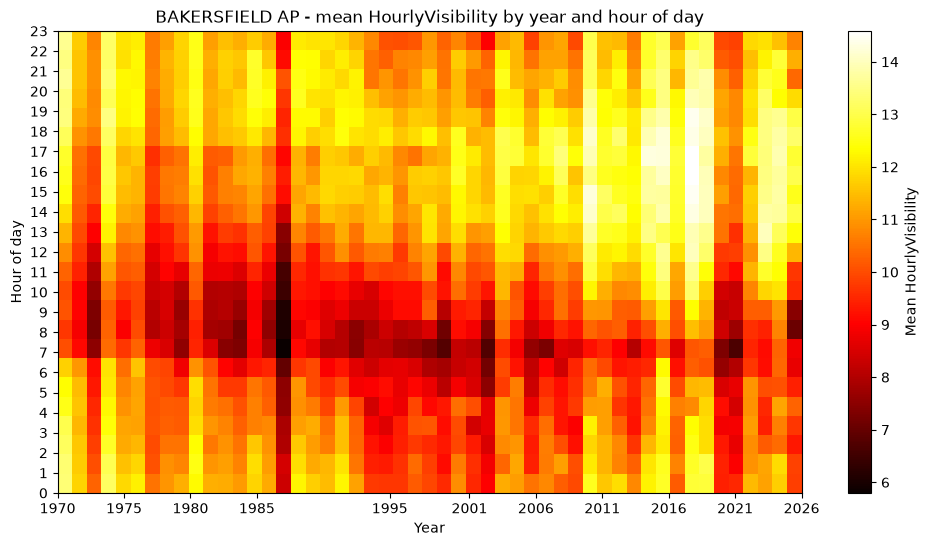

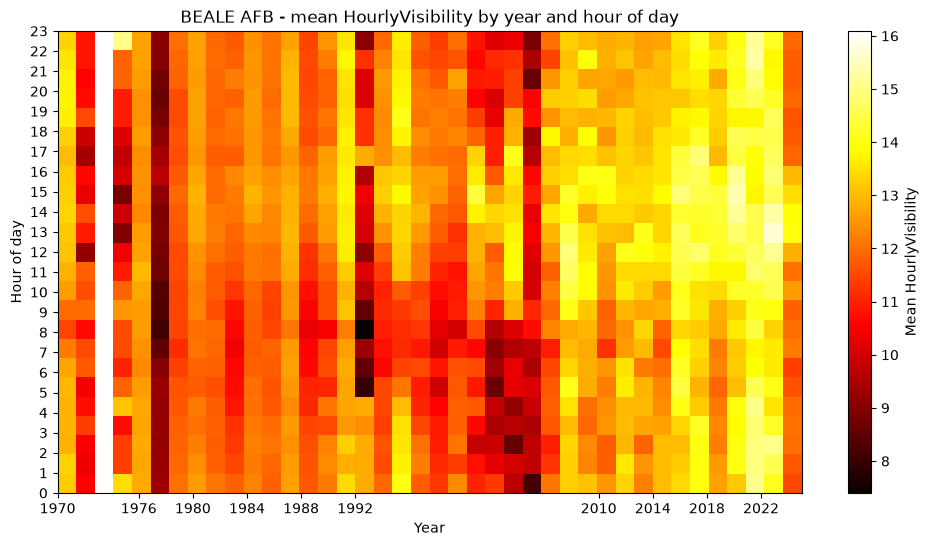

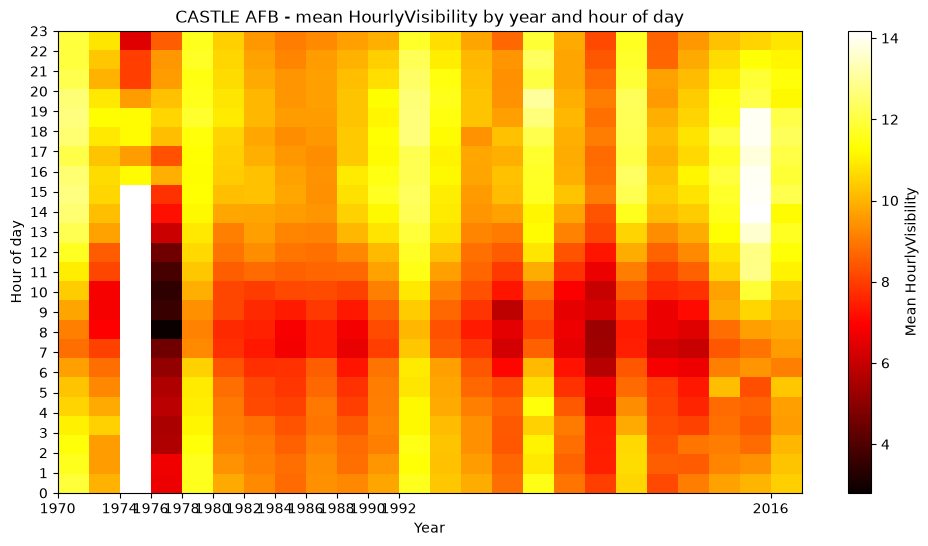

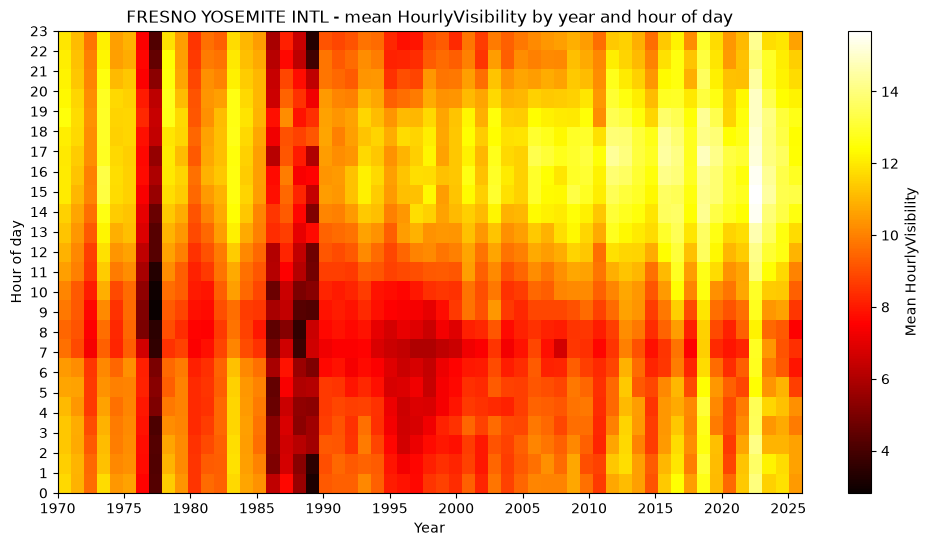

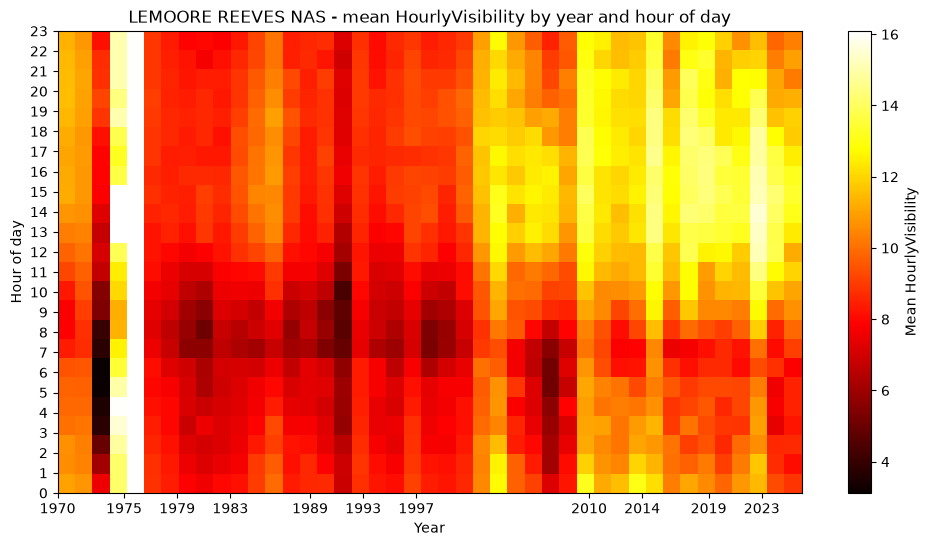

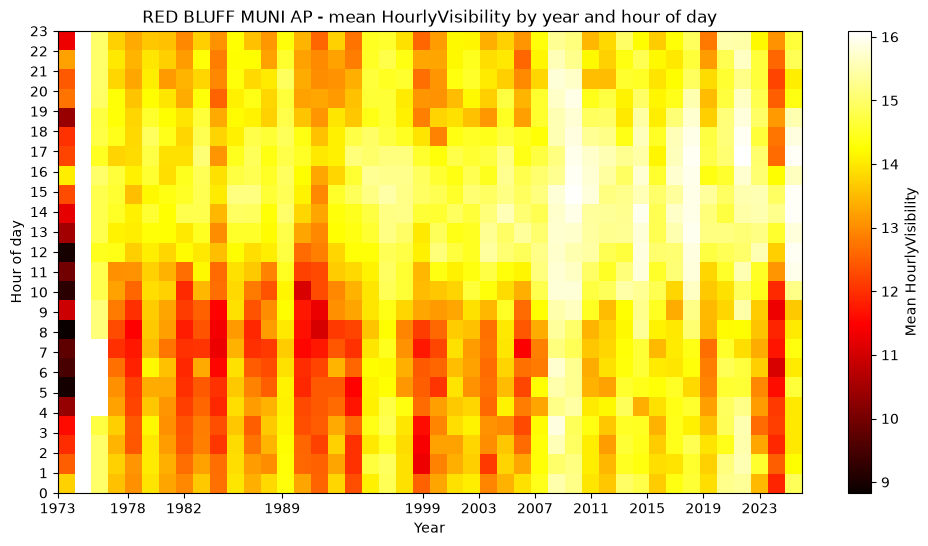

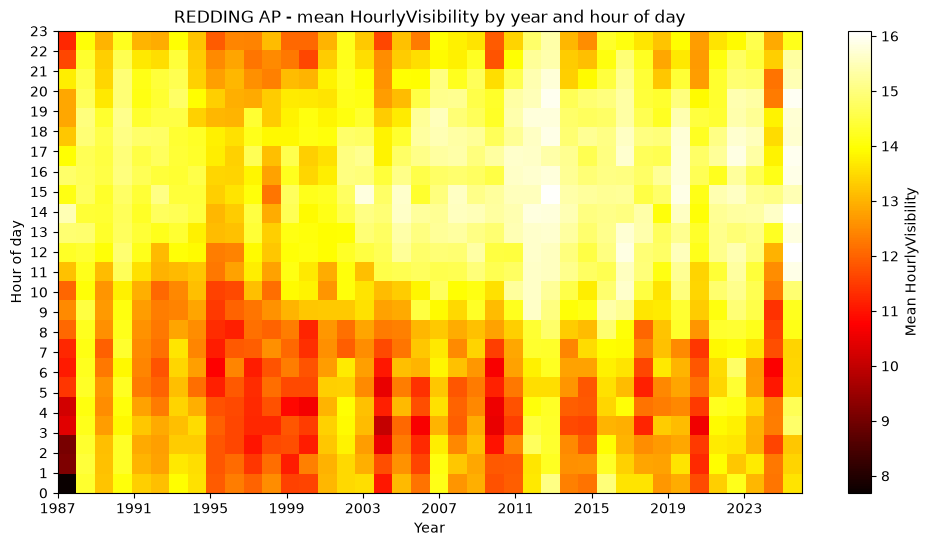

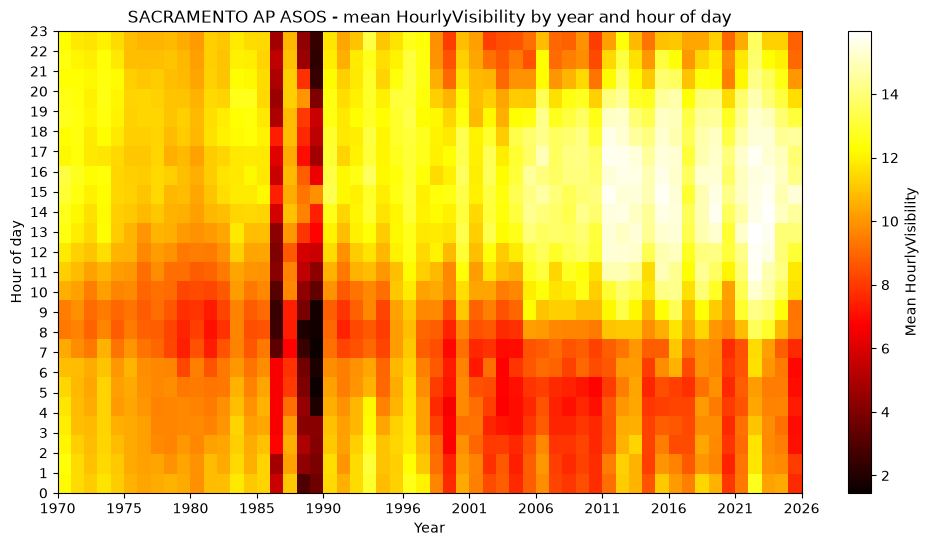

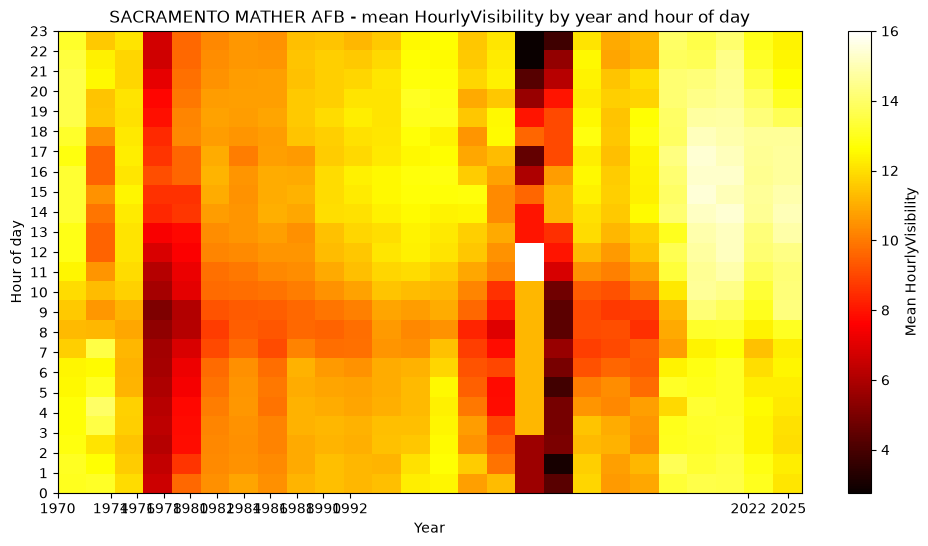

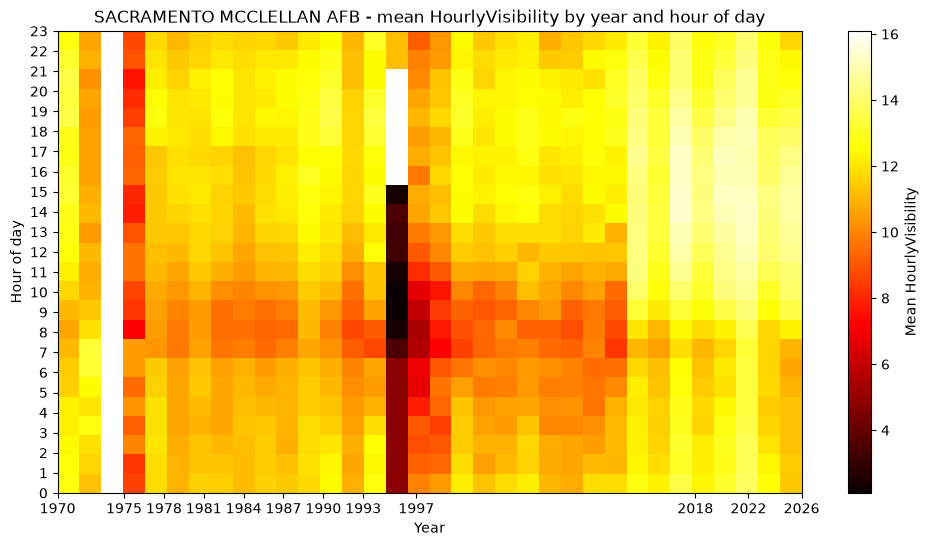

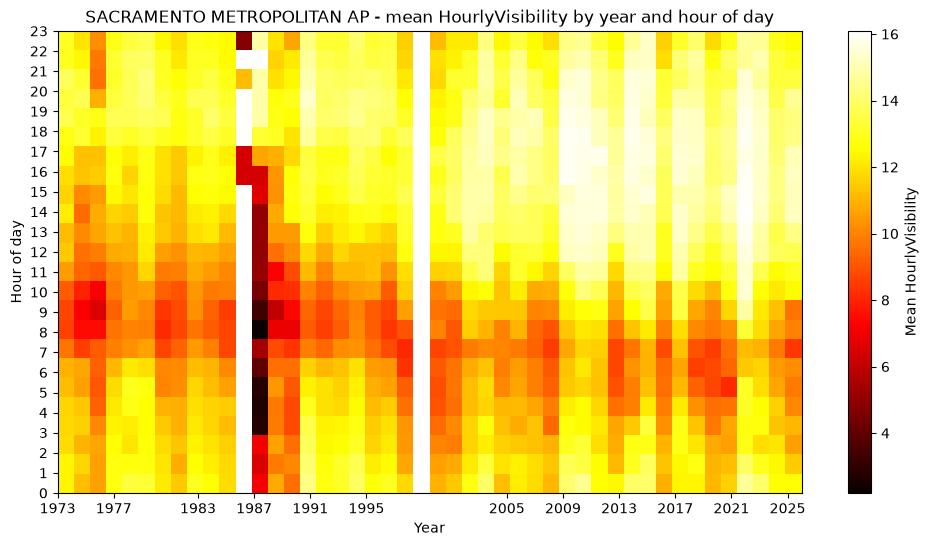

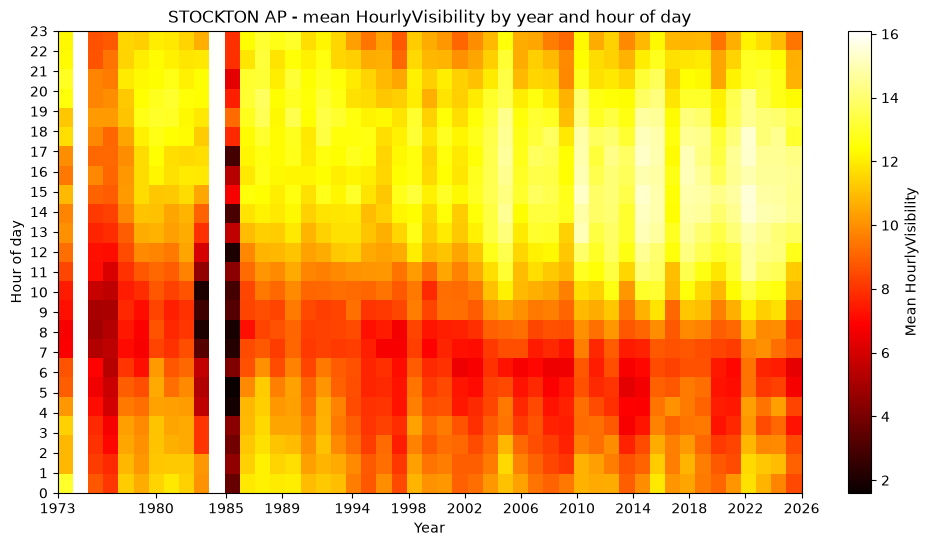

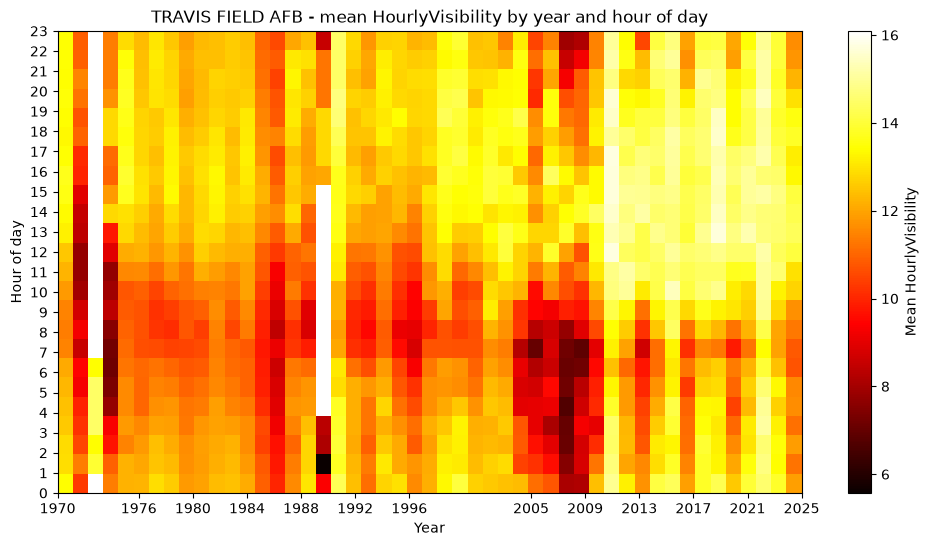

In [19]:
for station in stations:
    station_data = hourly_visibility_by_station_year_hour[
        hourly_visibility_by_station_year_hour["STATION"] == station
    ].copy()
    # only use years from 1970 to 2016
    station_data = station_data[(station_data["year"] >= 1970) & (station_data["year"] <= 2026)]


    if station_data.empty:
        continue

    pivot2 = (
        station_data
        .pivot(index="hour", columns="year", values="mean_visibility")
        .sort_index()
    )

    if pivot2.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(
        pivot2.values,
        aspect="auto",
        origin="lower",
        cmap="hot",
        extent=[pivot2.columns.min(), pivot2.columns.max(), pivot2.index.min(), pivot2.index.max()],
    )

    ax.set_title(f"{station} - mean HourlyVisibility by year and hour of day")
    ax.set_xlabel("Year")
    ax.set_ylabel("Hour of day")
    ax.set_yticks(range(0, 24))
    ax.set_xticks(sorted(pivot2.columns.unique())[::max(1, len(pivot2.columns) // 10)])
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Mean HourlyVisibility")

    # plt.tight_layout()
    plt.show()
    plt.close(fig)

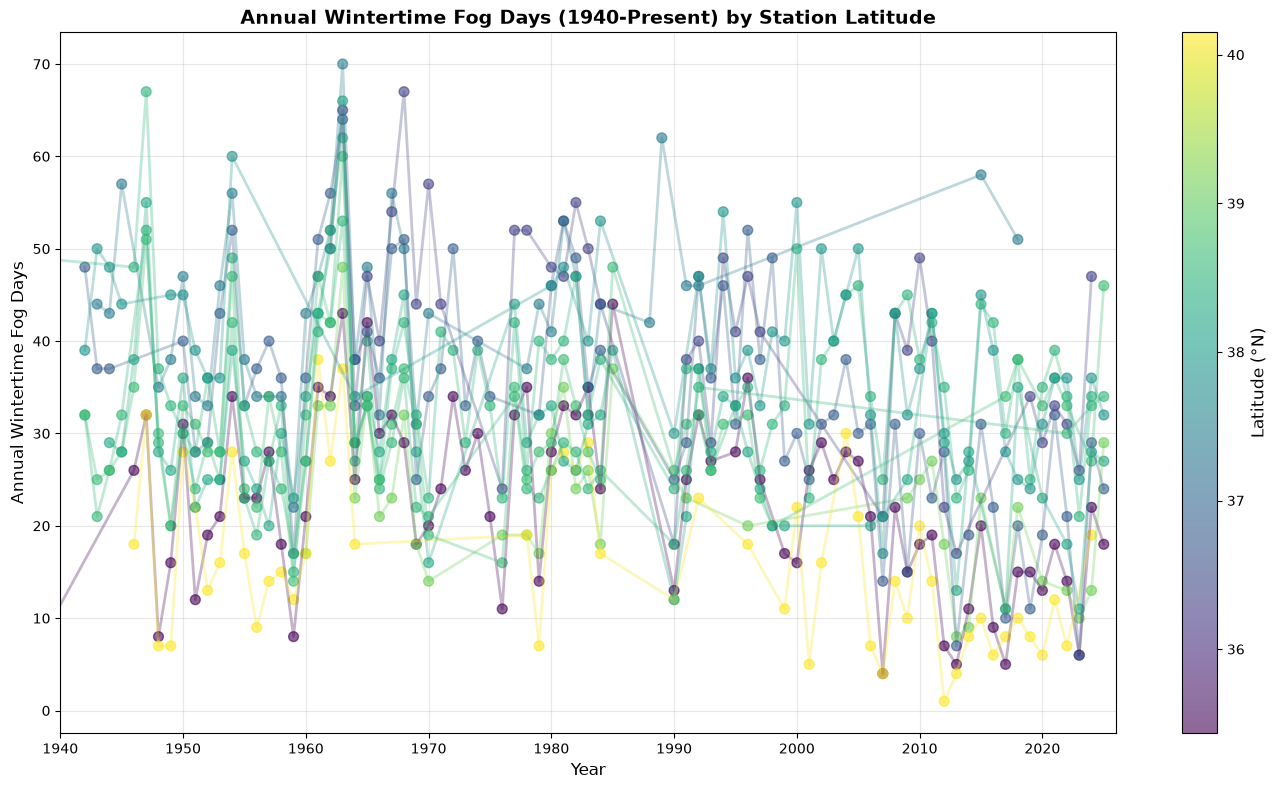

In [24]:
# Prepare data for plotting annual wintertime fog days by latitude
plot_data = annual_compare.merge(
    station_locations[['STATION', 'LATITUDE']],
    on='STATION',
    how='left'
).dropna(subset=['LATITUDE'])

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Create scatter plot with color gradient by latitude
scatter = ax.scatter(
    plot_data['year'],
    plot_data['fog_days'],
    c=plot_data['LATITUDE'],
    s=50,
    alpha=0.6,
    cmap='viridis',
    # edgecolors='black',
    # linewidth=0.5
)

#connect points with a line for each station
for station, group in plot_data.groupby('STATION'):
    ax.plot(
        group['year'],
        group['fog_days'],
        alpha=0.3,
        linewidth=2,
        # make the line color correspond to the station's latitude color in the scatter plot
        color=plt.cm.viridis((group['LATITUDE'].iloc[0] - plot_data['LATITUDE'].min()) / (plot_data['LATITUDE'].max() - plot_data['LATITUDE'].min()))
    )

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual Wintertime Fog Days', fontsize=12)
ax.set_title('Annual Wintertime Fog Days (1940-Present) by Station Latitude', fontsize=14, fontweight='bold')
ax.set_xlim(1940, plot_data['year'].max() + 1)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Latitude (°N)', fontsize=12)

plt.tight_layout()
plt.show()

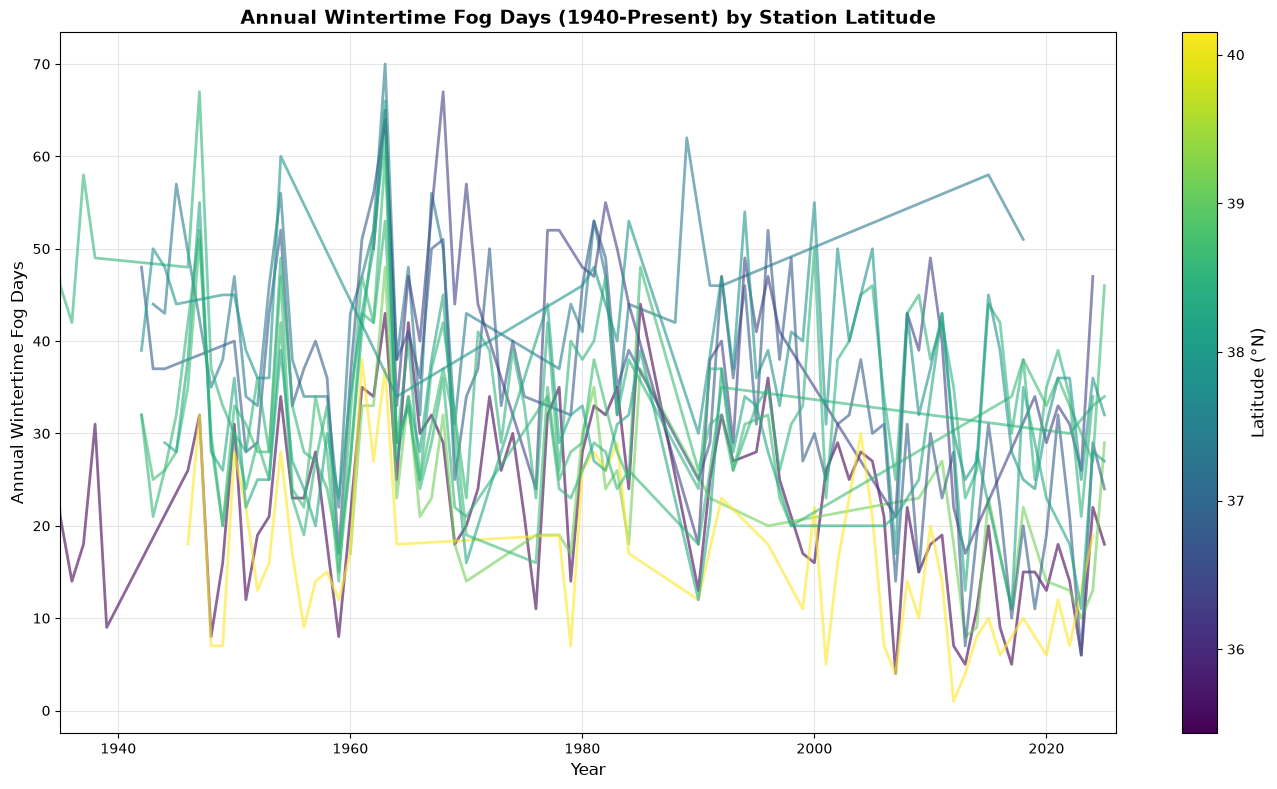

In [26]:
# Line-only version of the annual wintertime fog days plot (no point markers)
fig, ax = plt.subplots(figsize=(14, 8))

line_data = plot_data.dropna(subset=["LATITUDE"]).copy()
line_data = line_data.sort_values(["STATION", "year"])

lat_min = line_data["LATITUDE"].min()
lat_max = line_data["LATITUDE"].max()
norm = plt.Normalize(vmin=lat_min, vmax=lat_max)
cmap = plt.cm.viridis

for stn, group in line_data.groupby("STATION"):
    ax.plot(
        group["year"],
        group["fog_days"],
        color=cmap(norm(group["LATITUDE"].iloc[0])),
        alpha=0.6,
        linewidth=2
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual Wintertime Fog Days", fontsize=12)
ax.set_title("Annual Wintertime Fog Days (1940-Present) by Station Latitude", fontsize=14, fontweight="bold")
ax.set_xlim(1935, line_data["year"].max() + 1)
ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Latitude (°N)", fontsize=12)

plt.tight_layout()
plt.show()